In [19]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
import pandas as pd
warnings.filterwarnings('ignore', category=UserWarning)

from quantauto.data import load_market_data, load_multi_market_data

FM = ROOT / "market_data" / "ForMulti"
SP500_ASSETS = {
    'AAPL': FM / 'AAPL' / '1d.csv',
    'MSFT': FM / 'MSFT' / '1d.csv',
    'NVDA': FM / 'NVDA' / '1d.csv',
}

multi = load_multi_market_data(by_symbol=SP500_ASSETS, verbose=True)

rows = [
    {'Symbol': sym, 'Bars': len(lmd.data),
     'Start': lmd.data.index.min().date(), 'End': lmd.data.index.max().date()}
    for sym, lmd in multi.by_symbol.items()
]
pd.DataFrame(rows).set_index('Symbol')

loaded multi-asset market data: 3 symbol(s) [AAPL, MSFT, NVDA]
  AAPL: 1256 rows
  MSFT: 1256 rows
  NVDA: 1256 rows


,Bars,Start,End
Symbol,,,
AAPL,1256,2021-04-26,2026-04-24
MSFT,1256,2021-04-26,2026-04-24
NVDA,1256,2021-04-26,2026-04-24


[run_auto] starting pipeline
[run_auto] multi-asset input symbols=3
[run_auto:ranking] starting ranking multi-asset pipeline
[run_auto:ranking] aligned symbols=3 common_index_bars=1256
[run_auto:ranking] feature engineering preset=base symbols=3
[run_auto:ranking] features[AAPL] rows=1256 cols=21 warmup=34
[run_auto:ranking] features[AAPL] names=ret_1, log_ret_1, sma_20, ema_12, std_20, zscore_20, roc_10, rsi_14, macd_line, macd_signal, macd_hist, bb_mid, bb_upper, bb_lower, bb_width, bb_pctb, atr_14, obv, vol_ratio, hl_range, close_pos
[run_auto:ranking] features[MSFT] rows=1256 cols=21 warmup=34
[run_auto:ranking] features[MSFT] names=ret_1, log_ret_1, sma_20, ema_12, std_20, zscore_20, roc_10, rsi_14, macd_line, macd_signal, macd_hist, bb_mid, bb_upper, bb_lower, bb_width, bb_pctb, atr_14, obv, vol_ratio, hl_range, close_pos
[run_auto:ranking] features[NVDA] rows=1256 cols=21 warmup=34
[run_auto:ranking] features[NVDA] names=ret_1, log_ret_1, sma_20, ema_12, std_20, zscore_20, roc_1

/Users/mariochandra/Library/CloudStorage/OneDrive-TheUniversityofHongKong/year4.2/COMP4502/quantauto_build/.venv/lib/python3.9/site-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.48627e-24): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


[run_auto:ranking] training done best_model=ridge_rk
[run_auto:ranking] model=lgbm_lambdarank params={}
[run_auto:ranking] split=holdout train_size=2928 test_window=2025-05-02 04:00:00+00:00 -> 2026-04-23 04:00:00+00:00 (bars=735)
[run_auto:ranking] model=linreg_rk params={}
[run_auto:ranking] split=holdout train_size=2928 test_window=2025-05-02 04:00:00+00:00 -> 2026-04-23 04:00:00+00:00 (bars=735)
[run_auto:ranking] model=ridge_rk params={}
[run_auto:ranking] split=holdout train_size=2928 test_window=2025-05-02 04:00:00+00:00 -> 2026-04-23 04:00:00+00:00 (bars=735)
[run_auto:ranking] model=gbm_rk params={}
[run_auto:ranking] split=holdout train_size=2928 test_window=2025-05-02 04:00:00+00:00 -> 2026-04-23 04:00:00+00:00 (bars=735)
[run_auto:ranking] backtest done total_return=0.225406
[run_auto:ranking] backtest window: 2025-05-02 04:00:00+00:00 -> 2026-04-23 04:00:00+00:00 (bars=245)


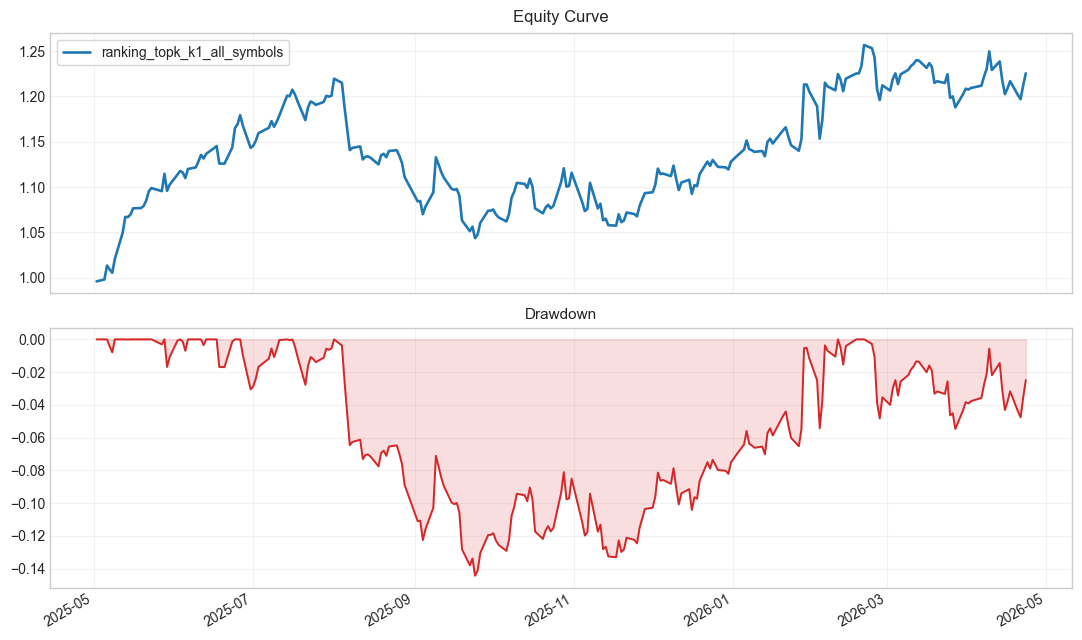

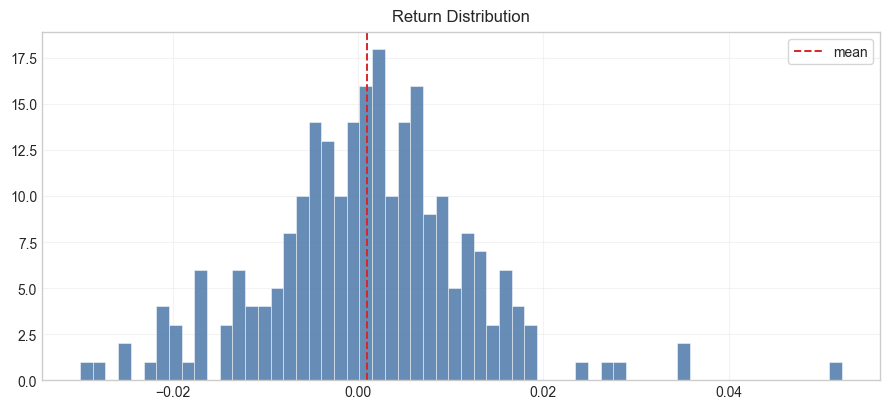

In [20]:
from quantauto.workflows import run_auto

results = run_auto(
    multi,
    target_type='ranking',
    target_horizon=1,
    feature_preset='base',
    execution_shift=1,
    test_split=0.2,
    walk_forward_folds=1,
    model_ids=('lgbm_lambdarank', 'linreg_rk', 'ridge_rk', 'gbm_rk'),
    training_time_budget='5m',
    ranking_top_k=1,
    multi_portfolio='per_symbol_only',
    backtest_scope='all_test_folds',
    fee_bps=2.0,
    slippage_bps=1.0,
    enable_backtest_plots=True,
    backtest_default_plots=('equity_curve', 'returns_distribution'),
    continue_on_error=True,
    verbose=2,
)